cuda


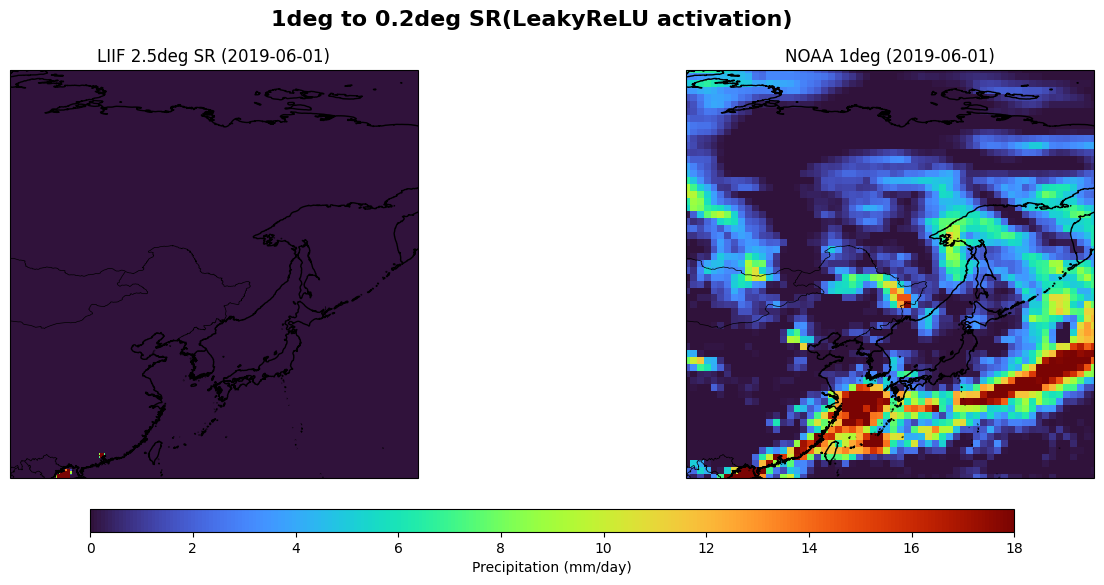

In [2]:
import torch
from models import make
from utils import make_coord
from torchvision import transforms
from PIL import Image
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import cartopy.crs as ccrs
import cartopy.feature as cfeature

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# === 0. config.yaml 로드 ===
config = OmegaConf.load('./save/_climate_2x/config.yaml')

# === 1. checkpoint 로드 및 모델 구성 ===
ckpt = torch.load('./save/_climate_2x/epoch-best.pth', map_location=device)
model = make({
    'name': ckpt['model']['name'],
    'args': ckpt['model']['args']
})
model.load_state_dict(ckpt['model']['sd'])
model.to(device)
model.eval()

# === 2. 날짜 설정 ===
time = '2019-06-01'

# === 3. 원본 데이터 로드 및 좌표 추출 ===
ds = xr.open_dataset('precip.day.mean.nc')
raw = ds.sel(time=time, latitude=slice(20, 79), longitude=slice(100, 159))['precip']
lat_range_lr = raw.latitude.values
lon_range_lr = raw.longitude.values
sample = raw.squeeze()
sample = np.nan_to_num(sample)
min_val, max_val = sample.min(), sample.max()
sample_norm = (sample - min_val) / (max_val - min_val)

# === 4. 흑백 → RGB 변환 후 64×64 리사이즈 ===
gray_img = (sample_norm * 255).astype(np.uint8)
rgb_img = np.stack([gray_img] * 3, axis=-1)
img = Image.fromarray(rgb_img).resize((60, 60))

# === 5. 입력 정규화 및 텐서화 ===
mean, std = config.data_norm.inp.sub[0], config.data_norm.inp.div[0]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([mean] * 3, [std] * 3)
])
inp_tensor = transform(img).unsqueeze(0).to(device)

# === 6. 복원 좌표 및 셀 정의 ===
coord = make_coord((256, 256)).unsqueeze(0).to(device)
cell = torch.full_like(coord, 1/256).to(device)

# === 7. 복원 수행 및 역정규화 ===
with torch.no_grad():
    model.gen_feat(inp_tensor)
    pred = model.query_rgb(coord, cell).view(256, 256, 3).clamp(0, 1).cpu().numpy()
    pred_gray = pred.mean(axis=-1)
    pred_actual = pred_gray * (max_val - min_val) + min_val  # mm/day

# === 8. 좌표계 생성 ===
lat_range_hr = np.linspace(20, 79, 256)
lon_range_hr = np.linspace(100, 159, 256)
lon_hr, lat_hr = np.meshgrid(lon_range_hr, lat_range_hr)
lon_lr, lat_lr = np.meshgrid(lon_range_lr, lat_range_lr)

# === 9. 지도 시각화 (복원 vs 원본) ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': ccrs.PlateCarree()})
vmin, vmax = 0, 18  # 공통 컬러바 범위

# --- (1) LIIF 복원 ---
axes[0].set_title(f'LIIF 2.5deg SR ({time})')
axes[0].set_extent([100, 159, 20, 79], crs=ccrs.PlateCarree())
im0 = axes[0].pcolormesh(lon_hr, lat_hr, pred_actual, cmap='turbo', shading='auto', vmin=vmin, vmax=vmax)
axes[0].coastlines(resolution='10m')
axes[0].add_feature(cfeature.BORDERS.with_scale('10m'), edgecolor='black', linewidth=0.5)
axes[0].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2)

# --- (2) 원본 ERA 데이터 ---
axes[1].set_title(f'NOAA 1deg ({time})')
axes[1].set_extent([100, 159, 20, 79], crs=ccrs.PlateCarree())
im1 = axes[1].pcolormesh(lon_lr, lat_lr, sample, cmap='turbo', shading='auto', vmin=vmin, vmax=vmax)
axes[1].coastlines(resolution='10m')
axes[1].add_feature(cfeature.BORDERS.with_scale('10m'), edgecolor='black', linewidth=0.5)
axes[1].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2)

# --- 공통 컬러바 ---
# --- 공통 컬러바 (아래로) ---
cbar = fig.colorbar(
    im1, ax=axes, orientation='horizontal',
    fraction=0.05, pad=0.15, aspect=40, label='Precipitation (mm/day)'
)

# 여유 공간 확보 (아래쪽에 컬러바 자리 마련)
fig.subplots_adjust(bottom=0.2)
fig.suptitle('1deg to 0.2deg SR(LeakyReLU activation)', fontsize=16, fontweight='bold')

# tight_layout은 제거 (컬러바와 충돌하므로)
# plt.tight_layout() ← 제거

plt.show()

In [ ]:
import torch
from collections import OrderedDict
import copy
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from PIL import Image
from torchvision import transforms
from models import make
from utils import make_coord
import pandas as pd
import os

# === 디바이스 설정 ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === 모델 로드 ===
ckpt = torch.load('save/_climate_2x/epoch-best.pth')
model_sd = ckpt['model']['sd']
args = copy.deepcopy(ckpt['model']['args'])
if 'encoder_spec' in args and 'args' in args['encoder_spec']:
    args['encoder_spec']['args'].pop('freeze', None)
model = make({'name': 'liif', 'args': args}).to(device)

# === state_dict 호환성 체크 및 로드 ===
new_model_sd = model.state_dict()
compatible_sd = OrderedDict()
for k in new_model_sd.keys():
    if k in model_sd and model_sd[k].shape == new_model_sd[k].shape:
        compatible_sd[k] = model_sd[k]
    else:
        print(f"Skip loading {k}: shape mismatch or not found")
model.load_state_dict(compatible_sd, strict=False)
model.eval()

# === 원본 데이터 로드 ===
ds = xr.open_dataset('precip.day.mean.nc')
raw = ds.sel(time=slice('2010-01-01', '2019-12-31'),
             latitude=slice(20, 79),
             longitude=slice(100, 159))['precip']
lat_range_lr = raw.latitude.values
lon_range_lr = raw.longitude.values
time_range = raw.time.values

# === 고해상도 좌표 생성 ===
lat_range_hr = np.linspace(20, 79, 256)
lon_range_hr = np.linspace(100, 159, 256)
lon_hr, lat_hr = np.meshgrid(lon_range_hr, lat_range_hr)
lon_lr, lat_lr = np.meshgrid(lon_range_lr, lat_range_lr)

# === 좌표 및 셀 생성 (한 번만)
coord = make_coord((256, 256)).unsqueeze(0).to(device)
cell = torch.ones_like(coord).to(device) / 256

# === 변환 정의
mean, std = 0.5, 0.5
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([mean] * 3, [std] * 3)
])

# === 저장 폴더 생성
os.makedirs('liif_outputs', exist_ok=True)

# === 시간 루프
for t_idx, time in enumerate(time_range):
    print(f"🔄 Processing: {str(time)[:10]} ({t_idx+1}/{len(time_range)})")

    # === 원시 데이터 추출 및 전처리 ===
    sample = raw.sel(time=time).squeeze().values  # (lat, lon)
    sample = np.nan_to_num(sample)
    min_val, max_val = sample.min(), sample.max()
    sample_norm = (sample - min_val) / (max_val - min_val + 1e-8)

    # === 이미지로 변환
    gray_img = (sample_norm * 255).astype(np.uint8)
    gray_img = gray_img.reshape(gray_img.shape[0], gray_img.shape[1], 1)
    rgb_img = np.repeat(gray_img, 3, axis=2)
    img = Image.fromarray(rgb_img).resize((60, 60))  # LR 사이즈 (e.g. 60x60)

    # === 텐서로 변환
    inp_tensor = transform(img).unsqueeze(0).to(device)

    # === 복원 수행
    with torch.no_grad():
        model.gen_feat(inp_tensor)
        pred = model.query_rgb(coord, cell).view(256, 256, 3).clamp(0, 1).cpu().numpy()
        pred_gray = pred.mean(axis=-1)
        pred_actual = pred_gray * (max_val - min_val) + min_val  # mm/day

    # === NetCDF 저장
    ds_out = xr.Dataset(
        data_vars={
            'precip': (('latitude', 'longitude'), pred_actual)
        },
        coords={
            'latitude': lat_range_hr,
            'longitude': lon_range_hr
        },
        attrs={
            'description': 'Super-resolved precipitation by LIIF',
            'units': 'mm/day'
        }
    )
    ds_out = ds_out.expand_dims(time=[pd.to_datetime(str(time))])
    save_path = f'liif_outputs/liif_sr_precip_{str(time)[:10]}.nc'
    ds_out.to_netcdf(save_path)
    print(f"✅ Saved: {save_path}")


🔄 Processing: 2010-01-01 (1/3652)
✅ Saved: liif_outputs/liif_sr_precip_2010-01-01.nc
🔄 Processing: 2010-01-02 (2/3652)
✅ Saved: liif_outputs/liif_sr_precip_2010-01-02.nc
🔄 Processing: 2010-01-03 (3/3652)
✅ Saved: liif_outputs/liif_sr_precip_2010-01-03.nc
🔄 Processing: 2010-01-04 (4/3652)
✅ Saved: liif_outputs/liif_sr_precip_2010-01-04.nc
🔄 Processing: 2010-01-05 (5/3652)
✅ Saved: liif_outputs/liif_sr_precip_2010-01-05.nc
🔄 Processing: 2010-01-06 (6/3652)
✅ Saved: liif_outputs/liif_sr_precip_2010-01-06.nc
🔄 Processing: 2010-01-07 (7/3652)
✅ Saved: liif_outputs/liif_sr_precip_2010-01-07.nc
🔄 Processing: 2010-01-08 (8/3652)
✅ Saved: liif_outputs/liif_sr_precip_2010-01-08.nc
🔄 Processing: 2010-01-09 (9/3652)
✅ Saved: liif_outputs/liif_sr_precip_2010-01-09.nc
🔄 Processing: 2010-01-10 (10/3652)
✅ Saved: liif_outputs/liif_sr_precip_2010-01-10.nc
🔄 Processing: 2010-01-11 (11/3652)
✅ Saved: liif_outputs/liif_sr_precip_2010-01-11.nc
🔄 Processing: 2010-01-12 (12/3652)
✅ Saved: liif_outputs/liif_s

KeyboardInterrupt: 

: 

In [ ]:
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# === 1. 하이퍼파라미터 설정 ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
min_val, max_val = 0.0, 20.0  # 강수량 단위(mm/day)

# === 2. 모델 입력을 위한 정규화 설정 ===
mean, std = 0.5, 0.5  # 학습 당시 config 기준
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([mean]*3, [std]*3)
])

# === 3. 이미지 불러오기 및 전처리 ===
img = Image.open('load/climate/climate_val_daily60/04015.png')  # 03833.png
img_tensor = transform(img).unsqueeze(0).to(device)  # (1, 3, H, W)

# === 4. 복원 좌표/셀 정의 ===
def make_coord(shape):
    h, w = shape
    coord_x = torch.linspace(0, 1, w)
    coord_y = torch.linspace(0, 1, h)
    grid_y, grid_x = torch.meshgrid(coord_y, coord_x, indexing='ij')
    coord = torch.stack([grid_x, grid_y], dim=-1)  # (H, W, 2)
    return coord.view(-1, 2)

coord = make_coord((300, 300)).unsqueeze(0).to(device)  # (1, H*W, 2)
cell = torch.ones_like(coord) / 256

# === 5. 모델 추론 ===
model.eval()
with torch.no_grad():
    model.gen_feat(img_tensor)
    pred = model.query_rgb(coord, cell)  # (1, H*W, 3)
    pred = pred.view(300, 300, 3).clamp(0, 1).cpu().numpy()
    pred_gray = pred.mean(axis=-1)
    pred_actual = pred_gray * (max_val - min_val) + min_val  # mm/day

# === 6. 시각화 ===
lat_range = np.linspace(20, 50, 300)
lon_range = np.linspace(100, 150, 300)
lon, lat = np.meshgrid(lon_range, lat_range)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
vmin, vmax = 0, 18
ax.set_title('LIIF Inference on 04010.png')
ax.set_extent([100, 150, 20, 50], crs=ccrs.PlateCarree())
im = ax.pcolormesh(lon, lat, pred_actual, cmap='turbo', shading='auto', vmin=vmin, vmax=vmax)
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS.with_scale('10m'), edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2)
fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, label='Precipitation (mm/day)')
plt.show()
